In [1]:
import numpy as np
import scipy.sparse as sp
from sympleq.core.paulis._typing import (HilbertOperator, ScalarType, TableauType, DimensionsLike, 
                                         PhasesLike, WeightsLike, IntArrayLike)
from sympleq.core.symmetries.pauli import symplectic_reduction_qudit
from sympleq.core.paulis import PauliSum, PauliString
from sympleq.utils import int_to_bases, bases_to_int
from sympleq.core.circuits import Circuit
from sympleq.core.circuits.gates import GATES, PauliGate, Gate

# Convenience aliases
H = GATES.H
CX = GATES.CX
S = GATES.S
SWAP = GATES.SWAP
Pauli_X = GATES.X
Pauli_Y = GATES.Y
Pauli_Z = GATES.Z

In [ ]:
def string_to_hilbert(dimensions: DimensionsLike, x_exp: IntArrayLike, z_exp: IntArrayLike) -> sp.csr_matrix:
    dimensions = np.asarray(dimensions, dtype=np.int64)
    x_exp = np.asarray(x_exp, dtype=np.int64)
    z_exp = np.asarray(z_exp, dtype=np.int64)

    n_qudits = dimensions.size
    D = np.prod(dimensions)

    n_mod = np.mod(x_exp, dimensions)
    m_mod = np.mod(z_exp, dimensions)

    indptr = np.arange(D + 1, dtype=np.int64)
    indices = np.zeros(D, dtype=np.int64)

    rows = np.arange(D, dtype=np.int64)

    phase_angle = np.zeros(D, dtype=np.float64)

    # Reusable work arrays for in-place computations
    digit = np.empty(D, dtype=np.int64)
    indices_temp = np.empty(D, dtype=np.int64)
    phase_temp = np.empty(D, dtype=np.float64)

    for n in range(n_qudits):
        d = dimensions[n]
        stride = np.prod(dimensions[n + 1 :])

        np.floor_divide(rows, stride, out=digit)
        np.mod(digit, d, out=digit)

        np.subtract(digit, n_mod[n], out=digit)
        np.mod(digit, d, out=digit)

        np.multiply(digit, stride, out=indices_temp)
        np.add(indices, indices_temp, out=indices)

        coeff = 2.0 * np.pi * m_mod[n] / d
        np.multiply(digit, coeff, out=phase_temp)
        np.add(phase_angle, phase_temp, out=phase_angle)

    data = np.empty(D, dtype=np.complex128)
    np.cos(phase_angle, out=data.real)
    np.sin(phase_angle, out=data.imag)
    data.real[np.abs(data.real) < 1e-15] = 0.0
    data.imag[np.abs(data.imag) < 1e-15] = 0.0

    return sp.csr_matrix(
        (data, indices, indptr),
        shape=(D, D),
        dtype=np.complex128,
        copy=False,
    )

def q_s(N):
    return PauliSum.from_string(['x0z0', 'x0z1'], [2] , [np.cos(np.pi / N), 1j*np.sin(np.pi / N)], [0, 0])

def GaussOperator(n_qubits: int, d: int, Q_qs = True) -> PauliSum:
    N = 2 ** n_qubits
    if Q_qs:
        Gs = q_s(N)
        P = PauliSum.from_hilbert_space(string_to_hilbert([N],[0],[1]).toarray(), [2]*n_qubits)
        for i in range(d):
            Gs = Gs @ P.hermitian_conjugate() @ P
    else:
        P = PauliSum.from_hilbert_space(string_to_hilbert([N],[0],[1]).toarray(), [2]*n_qubits)
        Gs = P.hermitian_conjugate() @ P
        for i in range(1, d):
            Gs = Gs @ P.hermitian_conjugate() @ P
    
    return Gs

def coefficient_Zn(s_vec):
    n_qubits = len(s_vec)
    value = 0
    omega = np.exp(1j * np.pi)
    for i in range(2**n_qubits):
        bin_form = int_to_bases(i, [2]*n_qubits)
        exponent = np.dot(bin_form, s_vec) + i/2**(n_qubits-1)
        value += omega ** exponent

    value = value/(2**n_qubits)
    return value


def Zn(n_qubits):
    tableau = np.zeros(( 2**n_qubits- 2**(n_qubits-1), 2 * n_qubits), dtype=int)
    coeffs = []
    for i,s in enumerate(range(2**(n_qubits-1), 2**n_qubits)):
        s_vec = int_to_bases(s, [2]*n_qubits)
        tableau[i, n_qubits:] = s_vec
        coeffs.append(coefficient_Zn(s_vec))
    return PauliSum(tableau, dimensions=[2]*n_qubits, weights=coeffs)

def Xn(n_qubits):
    dim = 2 ** n_qubits
    M = string_to_hilbert([dim],[1],[0]) 
    P_qudit = PauliSum.from_hilbert_space(M.toarray(), [2]*n_qubits)
    return P_qudit

def path_list(s):
    paths = [[0]*len(s)]
    for a in range(len(s)):
        while paths[-1][a] < s[a]:
            new_path = paths[-1].copy()
            new_path[a] += 1
            paths.append(new_path)
    return paths[:-1]

class LatticeHamiltonian:
    # TODO: Add docstring
    # TODO: Make Xn more efficient by finding mathematical expression for the coefficients instead of summing over all strings
    def __init__(self, n_sites, dim, n_qubits, m_0=1, g_0=1, lambda_pl = 1, Q_check=True):
        self.n_sites = n_sites
        self.dim = dim
        self.n_qubits = n_qubits
        self.m_0 = m_0
        self.g_0 = g_0
        self.lambda_pl = lambda_pl
        self.total_qubits = n_sites**dim * (dim * n_qubits + 1)

        # predefine the Xn and Zn 2^n qudit X and Z operators for n qubits for efficiency
        self.Xn = Xn(n_qubits)
        self.Zn = Zn(n_qubits)

        self.Q_check = Q_check

        # Assemble Hamiltonian as sum of individual terms
        self.H = self.H_mat() + self.H_hop() + self.H_el() + self.H_pl()

        # Combine equivalent Paulis and round weights to avoid numerical issues
        self.H.combine_equivalent_paulis()
        self.H.weights = np.around(self.H.weights,8)

    def P(self, s, l):
        '''
        Constructs the P operator for a given edge l (1 to dim) at site s (integer vector) together with the 
        identities on the other qubits. 
        '''
        i = bases_to_int(s[::-1], [self.n_sites]*self.dim)
        P_z = self.Zn
        n_qubits_before = self.n_sites**self.dim + (i) * self.dim * self.n_qubits + (l-1) * self.n_qubits
        n_qubits_after = (self.n_sites**self.dim - i - 1) * self.dim * self.n_qubits + (self.dim - l) * self.n_qubits
        P_before = PauliSum(np.array([0]*(2*n_qubits_before)), [2]*n_qubits_before, [1])
        if n_qubits_after == 0:
            P_out = P_before @ P_z
        else:
            P_after = PauliSum(np.array([0]*(2*n_qubits_after)), [2]*n_qubits_after, [1])
            P_out = P_before @ P_z @ P_after
        
        if self.Q_check:
            if P_out.n_qudits() != self.total_qubits:
                raise ValueError(f"Output PauliSum has {P_out.n_qudits()} qudits, expected {self.total_qubits}.")
        return P_out

    def Q(self, s, l):
        '''
        Constructs the Q operator for a given edge l (1 to dim) at site s (integer vector) together with the 
        identities on the other qubits. 
        '''
        i = bases_to_int(s[::-1], [self.n_sites]*self.dim)
        P_x = self.Xn
        n_qubits_before = self.n_sites**self.dim + (i) * self.dim * self.n_qubits + (l-1) * self.n_qubits
        n_qubits_after = (self.n_sites**self.dim - i - 1) * self.dim * self.n_qubits + (self.dim - l) * self.n_qubits
        P_before = PauliSum(np.array([0]*(2*n_qubits_before)), [2]*n_qubits_before, [1])
        if n_qubits_after == 0:
            Q_out = P_before @ P_x
        else:
            P_after = PauliSum(np.array([0]*(2*n_qubits_after)), [2]*n_qubits_after, [1])
            Q_out = P_before @ P_x @ P_after
        
        if self.Q_check:
            if Q_out.n_qudits() != self.total_qubits:
                raise ValueError(f"Output PauliSum has {Q_out.n_qudits()} qudits, expected {self.total_qubits}.")
        return Q_out

    def psi(self, i):
        '''
        Constructs the psi state for a given index of a site i.
        '''
        s = int_to_bases(i, [self.n_sites]*self.dim)[::-1]
        # sigma^+ term
        tableau = np.zeros((2, 2*self.total_qubits), dtype=int)
        tableau[0,i] = 1
        tableau[1,i] = 1
        tableau[1,i + self.total_qubits] = 1
        P_sigma = PauliSum(tableau, dimensions=[2]*self.total_qubits, weights=[1/2,-1/2])
        # print(P_sigma)

        # Path term
        tableau = np.zeros((1, 2*self.total_qubits), dtype=int)
        path = path_list(s)
        # print(path)
        for p in path:
            p_index = bases_to_int(p[::-1], [self.n_sites]*self.dim)
            tableau[0, p_index + self.total_qubits] = 1
        P_path = PauliSum(tableau, dimensions=[2]*self.total_qubits, weights=[1])
        # print(P_path)
        P_out = P_sigma * P_path
        if self.Q_check:
            if P_out.n_qudits() != self.total_qubits:
                raise ValueError(f"Output PauliSum has {P_out.n_qudits()} qudits, expected {self.total_qubits}.")
        P_out.remove_zero_weight_paulis()
        P_out.combine_equivalent_paulis()
        return P_out

    def H_mat(self):
        P_total = PauliSum(np.array([0]*(2*self.total_qubits)), [2]*self.total_qubits, [0])
        for i in range(self.n_sites**self.dim):
            s = int_to_bases(i, [self.n_sites]*self.dim)[::-1]
            tableau = np.zeros((2, 2*self.total_qubits), dtype=int)
            tableau[1,i+self.total_qubits] = 1
            P_site = PauliSum(tableau, dimensions=[2]*self.total_qubits, weights=[(-1)**(i) * self.m_0/2,(-1)**(i+1) * self.m_0/2])
            P_total = P_total + P_site
        P_total.remove_zero_weight_paulis()
        P_total.combine_equivalent_paulis()
        return P_total

    def H_hop(self):
        P_total = PauliSum(np.array([0]*(2*self.total_qubits)), [2]*self.total_qubits, [0])
        for i in range(self.n_sites**self.dim):
            s = int_to_bases(i, [self.n_sites]*self.dim)[::-1]
            for l in range(1, self.dim+1):
                s_adj = s.copy()
                s_adj[l-1] = (s_adj[l-1] + 1) % self.n_sites
                i_adj = bases_to_int(s_adj[::-1], [self.n_sites]*self.dim)

                psi_i = self.psi(i)
                psi_i_adj = self.psi(i_adj)
                Qsl = self.Q(s,l)

                # Term 1
                P_hop_1 = psi_i_adj.hermitian_conjugate() * Qsl * psi_i

                # Term 2
                P_hop_2 = psi_i.hermitian_conjugate() * Qsl.hermitian_conjugate() * psi_i_adj

                P_total = P_total + P_hop_1 + P_hop_2
        P_total.remove_zero_weight_paulis()
        return P_total

    def H_el(self):
        P_total = PauliSum(np.array([0]*(2*self.total_qubits)), [2]*self.total_qubits, [0])
        for i in range(self.n_sites**self.dim):
            s = int_to_bases(i, [self.n_sites]*self.dim)[::-1]
            for l in range(1, self.dim+1):
                P_1 = self.P(s,l)
                P_2 = P_1.hermitian_conjugate()
                P_total = P_total + self.g_0 * (P_1 + P_2)
        P_total.remove_zero_weight_paulis()
        return P_total

    def W(self,s,k,l):
        i = bases_to_int(s[::-1], [self.n_sites]*self.dim)
        s_adj1 = s.copy()
        s_adj1[k-1] = (s_adj1[k-1] + 1) % self.n_sites
        i_adj1 = bases_to_int(s_adj1[::-1], [self.n_sites]*self.dim)

        s_adj2 = s.copy()
        s_adj2[l-1] = (s_adj2[l-1] + 1) % self.n_sites
        i_adj2 = bases_to_int(s_adj2[::-1], [self.n_sites]*self.dim)

        Wp = self.Q(s,k) * self.Q(s_adj1,l) * self.Q(s_adj2,k).hermitian_conjugate() * self.Q(s,l).hermitian_conjugate()

        return Wp

    def H_pl(self):
        P_total = PauliSum(np.array([0]*(2*self.total_qubits)), [2]*self.total_qubits, [0])
        for i in range(self.n_sites**self.dim):
            s = int_to_bases(i, [self.n_sites]*self.dim)[::-1]
            for k in range(1, self.dim+1):
                for l in range(k+1, self.dim+1):
                    Wp = self.W(s,k,l)
                    P_pl = Wp + Wp.hermitian_conjugate()
                    P_total = P_total + self.lambda_pl * P_pl
        P_total.remove_zero_weight_paulis()
        return P_total

def test_symmetry(symmetry, hamiltonian):
    if isinstance(symmetry, Gate):
        return symmetry.act(hamiltonian, tuple(np.arange(hamiltonian.n_qudits()))).is_close(hamiltonian, literal=False)
    elif isinstance(symmetry, Circuit):
        return symmetry.act(hamiltonian).is_close(hamiltonian, literal=False)
    else:
        raise Exception('Symmetry must be a Gate or Circuit')

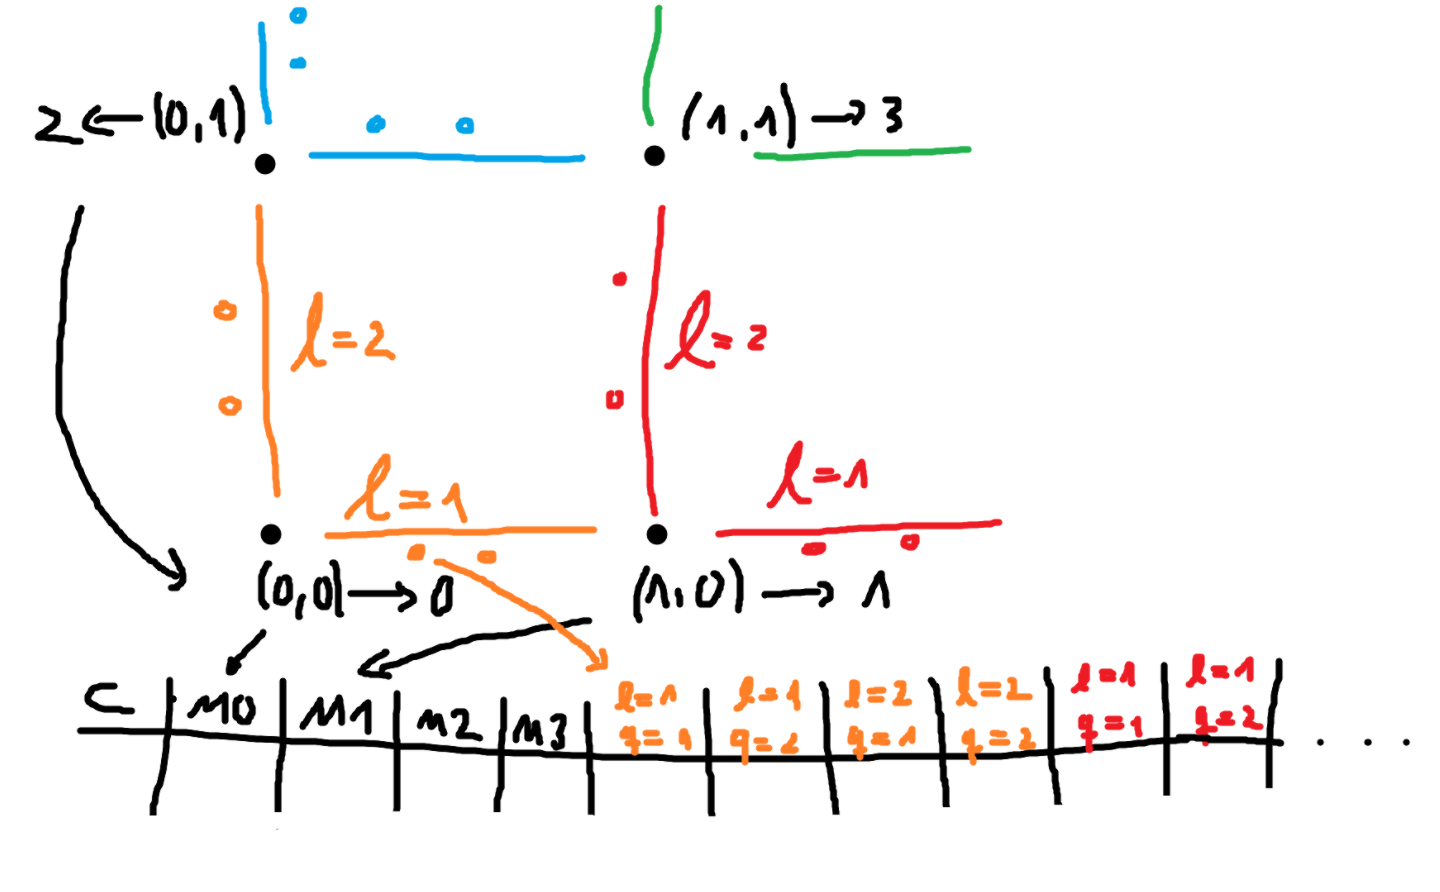

In [ ]:
# Encoding:
# First Matter Qubits
# Then the eta gauge qubits for the l edges of the corresponding matter qubit
# Example for 4 matter qubits in 2 dimensions with 2 qubits per gauge qubit:
# M1 - M2 - M3 - M4 - E1M1Q1 - E1M1Q2 - E2M1Q1 - E2M1Q2 - E1M2Q1 - E1M2Q2 - E2M2Q1 - E2M2Q2 - ...

LH = LatticeHamiltonian(n_sites=2, dim=2, n_qubits=2)
print(LH.H)

(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z1 x0z0 | 0 
(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z1 x0z1 | 0 
(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z1 x0z0 x0z0 x0z0 | 0 
(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z1 x0z1 x0z0 x0z0 | 0 
(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z1 x0z0 x0z0 x0z0 x0z0 x0z0 | 0 
(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z1 x0z1 x0z0 x0z0 x0z0 x0z0 | 0 
(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z1 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 | 0 
(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z1 x0z1 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 | 0 
(1+0j)     |x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0z0 x0

In [4]:
# Examples for how to create Circuits

# empty Circuit
circuit = Circuit.empty(dimensions = [2,2,2])

# Circuit with gates
circuit = Circuit(dimensions = [2,2,2], gates = [H,CX,CX], qudit_indices = [tuple([1]),(0,1),(2,1)])

# Adding Gates to circuits
circuit.add_gate(H, 0)
circuit.add_gate(CX, 0, 1)
circuit.add_gate(S, 1)
circuit.add_gate(SWAP, 1, 2)

# Paulis
circuit.add_gate(Pauli_X, 1)
circuit.add_gate(Pauli_Y, 1)
circuit.add_gate(Pauli_Z, 1)

# Pauli Strings
p = PauliString.from_string('x0z1 x1z1 x1z0', dimensions=[2,2,2])
PS = PauliGate(p)
circuit.add_gate(PS, 0, 1 ,2)

print(circuit)
print()

# concatenating circuits
circuit1 = Circuit(dimensions = [2,2,2], gates = [H,CX,CX], qudit_indices = [tuple([1]),(0,1),(2,1)])
circuit2 = Circuit(dimensions = [2,2,2], gates = [S,S,S], qudit_indices = [tuple([0]),tuple([1]),tuple([2])])

circuit = circuit1 + circuit2

print(circuit)

Circuit on 3 qudits (dims=[np.int64(2), np.int64(2), np.int64(2)]):
  H (1,) 
  CX (0, 1) 
  CX (2, 1) 
  H (0,) 
  CX (0, 1) 
  S (1,) 
  SWAP (1, 2) 
  X (1,) 
  Y (1,) 
  Z (1,) 
  Pauli (0, 1, 2) 

Circuit on 3 qudits (dims=[np.int64(2), np.int64(2), np.int64(2)]):
  H (1,) 
  CX (0, 1) 
  CX (2, 1) 
  S (0,) 
  S (1,) 
  S (2,) 


In [ ]:
# Testing Symmetries

# first a random gate for a random Hamiltonian -- expected False
Ham_1 = PauliSum.from_random(dimensions=[2]*3, n_paulis=6)
print(Ham_1)
print()

Sym_1 = Circuit.from_random(dimensions=[2]*3, n_gates=5)
print(Sym_1)
print()

print(test_symmetry(Sym_1, Ham_1))
print()

# then a Hadamard on a Hadamard-symmetric Hamiltonian -- expected True
Ham_2 = PauliSum.from_string(["x0z1", "x1z0"],dimensions=[2]*1)
print(Ham_2)
print()

Sym_2 = Circuit.empty(dimensions=[2]*1)
Sym_2.add_gate(H, 0)
print(Sym_2)

print(test_symmetry(Sym_2, Ham_2))

(-0.8221819161710215+0j)|x0z0 x0z1 x0z0 | 0 
(-0.7279960472586287+0j)|x0z1 x1z0 x0z0 | 0 
(0.4277932488064302+0j) |x0z1 x0z0 x0z1 | 0 
(-0.4581677344411885+0j)|x0z0 x0z0 x1z1 | 0 
(0.10964422959747067+0j)|x1z1 x1z0 x0z1 | 0 
(0.46919333553329645+0j)|x0z1 x1z0 x0z1 | 0 


Circuit on 3 qudits (dims=[np.int64(2), np.int64(2), np.int64(2)]):
  S (2,) 
  H (2,) 
  SWAP (2, 0) 
  S (0,) 
  S (0,) 

False

(1+0j)|x0z1 | 0 
(1+0j)|x1z0 | 0 




TypeError: Circuit.add_gate() got an unexpected keyword argument 'dimensions'